# Comparing All Eight Models

### Table of contents
0. [Introduction](#0.-Introduction)
1. [Setup](#1.-Setup)
2. [Refitting all eight models](#2.-Refitting-all-eight-models)
3. [Comparing metrics](#3.-Comparing-metrics)
4. [Week 5 summary](#4.-Week-5-summary)
5. [Exercises](#5.-Exercises)

## 0. Introduction

Eight models across two weeks, five new this week:
1. Random Forest (`01_random_forest.ipynb`)
2. Ensemble Learning: Bagging and Boosting (`02_ensemble_learning.ipynb`)
3. Support Vector Machines (`03_svm.ipynb`)
4. Naive Bayes (`04_naive_bayes.ipynb`)

Plus week 4's Logistic Regression, KNN, and Decision Tree, refit here on `load_digits` so all eight face the same 10-class problem.

## 1. Setup

Same load, split, scale as notebooks 1 to 4, repeated here so this notebook runs on its own.

In [1]:
from sklearn.datasets import load_digits

data = load_digits(as_frame=True)
df = data.frame
X = df.drop(columns="target")
y = df["target"]

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2. Refitting all eight models

Logistic Regression (week 4, notebook 2):

In [4]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

KNN (week 4, notebook 3); `k=8` was week 4's cross-validated best:

In [5]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

Decision Tree (week 4, notebook 4):

In [6]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=8, random_state=42)
tree.fit(X_train_scaled, y_train)
y_pred_tree = tree.predict(X_test_scaled)

Random Forest (notebook 1):

In [7]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=200, random_state=42)
forest.fit(X_train_scaled, y_train)
y_pred_forest = forest.predict(X_test_scaled)

AdaBoost and Gradient Boosting (notebook 2):

In [8]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train_scaled, y_train)
y_pred_ada = ada.predict(X_test_scaled)

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)

SVM, RBF kernel (notebook 3):

In [9]:
from sklearn.svm import SVC

svm_rbf = SVC(kernel="rbf", C=1, gamma="scale")
svm_rbf.fit(X_train_scaled, y_train)
y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)

Naive Bayes (notebook 4):

In [10]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)

## 3. Comparing metrics

All eight, same dataset and split. With 10 classes, Precision/Recall/F1 need `average="macro"`, every digit weighted equally.

In [11]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_predictions = {
    "Logistic Regression": y_pred_logreg,
    "KNN (k=8)": y_pred_knn,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_forest,
    "AdaBoost": y_pred_ada,
    "Gradient Boosting": y_pred_gb,
    "SVM (RBF)": y_pred_svm_rbf,
    "Naive Bayes": y_pred_nb,
}

comparison = pd.DataFrame({
    name: {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="macro"),
        "Recall": recall_score(y_test, pred, average="macro"),
        "F1-score": f1_score(y_test, pred, average="macro"),
    }
    for name, pred in model_predictions.items()
})
comparison.round(4).T.sort_values("Accuracy", ascending=False)

,Accuracy,Precision,Recall,F1-score
SVM (RBF),0.9750,0.9760,0.9748,0.9748
Logistic Regression,0.9722,0.9721,0.9719,0.9719
KNN (k=8),0.9667,0.9684,0.9665,0.9666
Random Forest,0.9639,0.9644,0.9635,0.9634
Gradient Boosting,0.9528,0.9528,0.9525,0.9521
AdaBoost,0.8306,0.8362,0.8297,0.8284
Decision Tree,0.8028,0.8048,0.8023,0.8017
Naive Bayes,0.7417,0.8096,0.7408,0.7403


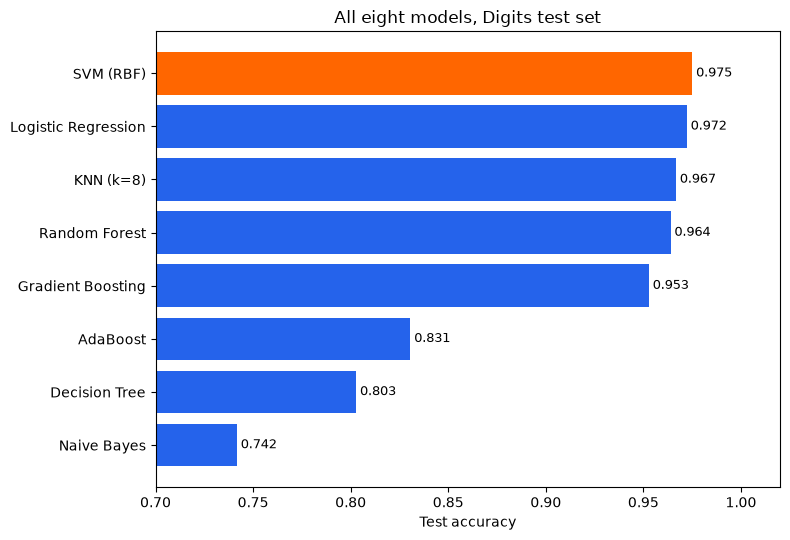

In [12]:
import matplotlib.pyplot as plt

accuracies = comparison.loc["Accuracy"].sort_values()
colors = ["#ff6600" if v == accuracies.max() else "#2563EB" for v in accuracies]

plt.figure(figsize=(8, 5.5))
plt.barh(accuracies.index, accuracies.values, color=colors)
for i, v in enumerate(accuracies.values):
    plt.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)
plt.xlim(0.7, 1.02)
plt.xlabel("Test accuracy")
plt.title("All eight models, Digits test set")
plt.tight_layout()
plt.show()

Naive Bayes is the clear outlier, as expected. Everything else lands in a similar high range, so the real choice between them comes down to speed, interpretability, and behavior on messier data, not the last percentage point of accuracy.

## 4. Week 5 summary

- **Random Forest**: many trees, random samples/features, vote (**Bagging**), plus feature importance.
- **Ensemble Learning**: combine weak models so mistakes cancel out. **Bagging** (parallel) and **Boosting** (sequential: AdaBoost, Gradient Boosting) are the two families.
- **SVM**: widest-margin boundary, set only by the support vectors; the kernel trick bends it non-linearly.
- **Naive Bayes**: Bayes' theorem plus an independence assumption, fast, but it costs accuracy on correlated pixels.
- No model needed code changes for 10 classes. Real choice rests on speed, interpretability, and generalization, not one leaderboard number.

## 5. Exercises

1. Using `GridSearchCV` (introduced conceptually in week 3), search over `max_depth in [2, 4, 6, 8, None]` and `min_samples_split in [2, 10, 30]` for `DecisionTreeClassifier` on the training data, with `cv=5`. Which combination wins, and how does its test accuracy compare to notebook 1's baseline `max_depth=8` tree?

2. Repeat notebook 1's `n_estimators` sweep (section 3.2) for Random Forest, but this time also track **fit time** (`%timeit` or `time.perf_counter()`). At what point does more accuracy stop being worth the extra training time?

3. Notebook 2's Gradient Boosting (section 2.3) used the default `learning_rate=0.1`. Try `learning_rate` values `[0.01, 0.05, 0.1, 0.3, 1.0]` at a fixed `n_estimators=100`, and plot test accuracy against `learning_rate`. Is there a clear best value?

4. Train an `SVC(kernel="poly", degree=3)` on the moons dataset and add it as a fourth panel next to notebook 3's linear/RBF comparison (section 2.3). Where does its boundary fall between the two?

5. Compare `GaussianNB`'s test accuracy, precision, and recall (notebook 4, `average="macro"`) against Random Forest's (notebook 1). How large is the gap on this image dataset? Would you expect it to be larger or smaller on a text-classification dataset, and why?

6. **Bringing it all together.** This week's digits dataset already showed all eight models handle a 10-class image problem without any code changes. Now check the opposite direction: a small, non-image, tabular dataset. Load `sklearn.datasets.load_wine(as_frame=True)` (13 chemical features, 3 classes) from week 4's final exercise, split with `stratify`, scale, fit all eight models from section 2 above with no changes beyond swapping the dataset in, and report test accuracy for each. Write two sentences on which model you'd pick for this dataset and why.